# Customer Transaction Prediction
**Models:** Logistic Regression (baseline), LightGBM, CatBoost (final proposed)  
**Objective:** Predict whether a customer will make a future transaction (target = 1).  
**Notes:** Dataset is numeric and known to be imbalanced. No missing values - No imputation required.

In [4]:
# 1. Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, classification_report, confusion_matrix, precision_recall_curve

from sklearn.linear_model import LogisticRegression
import lightgbm as lgb
from catboost import CatBoostClassifier

import warnings
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

In [6]:
# 2. Load data
cust_trans = pd.read_csv("train(1).csv")
print("Shape:", cust_trans.shape)
print("Missing values total:", cust_trans.isnull().sum().sum())
print("\nTarget distribution:\n", cust_trans['target'].value_counts(normalize=True).rename('proportion'))
cust_trans.head()

Shape: (200000, 202)
Missing values total: 0

Target distribution:
 target
0    0.89951
1    0.10049
Name: proportion, dtype: float64


,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
0,train_0,0,8.9255,-6.7863,11.9081,5.0930,11.4607,-9.2834,5.1187,18.6266,...,4.4354,3.9642,3.1364,1.6910,18.5227,-2.3978,7.8784,8.5635,12.7803,-1.0914
1,train_1,0,11.5006,-4.1473,13.8588,5.3890,12.3622,7.0433,5.6208,16.5338,...,7.6421,7.7214,2.5837,10.9516,15.4305,2.0339,8.1267,8.7889,18.3560,1.9518
2,train_2,0,8.6093,-2.7457,12.0805,7.8928,10.5825,-9.0837,6.9427,14.6155,...,2.9057,9.7905,1.6704,1.6858,21.6042,3.1417,-6.5213,8.2675,14.7222,0.3965
3,train_3,0,11.0604,-2.1518,8.9522,7.1957,12.5846,-1.8361,5.8428,14.9250,...,4.4666,4.7433,0.7178,1.4214,23.0347,-1.2706,-2.9275,10.2922,17.9697,-8.9996
4,train_4,0,9.8369,-1.4834,12.8746,6.6375,12.2772,2.4486,5.9405,19.2514,...,-1.4905,9.5214,-0.1508,9.1942,13.2876,-1.5121,3.9267,9.5031,17.9974,-8.8104


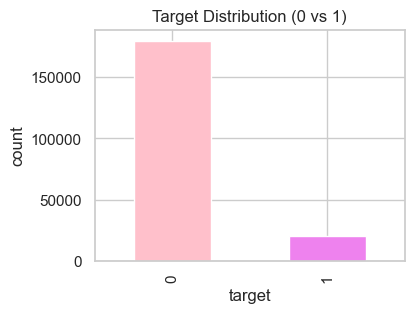

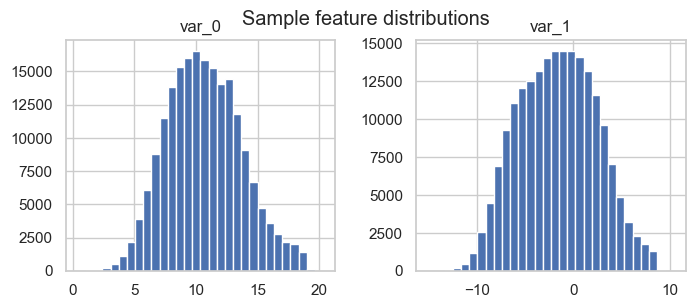

In [16]:
# 3. EDA

# Target Distribution
plt.figure(figsize=(4,3))
cust_trans['target'].value_counts().plot(kind='bar', color=['pink','violet'])
plt.title("Target Distribution (0 vs 1)")
plt.xlabel("target")
plt.ylabel("count")
plt.show()

# Feature Distribution
feat_cols = [c for c in cust_trans.columns if c not in ['ID_code','target']][:2]
cust_trans[feat_cols].hist(bins=30, figsize=(8,3))
plt.suptitle("Sample feature distributions")
plt.show()

**Interpretation:**  
1. The `target` proportions show a large majority for `0`, which implies dataset is imbalanced. In such cases, along with accuracy, ROC-AUC score an F1 score needs to be considered. To handle the imbalance, class_weights and special models need to be implied.
2. Sample features show smooth, bell-shaped numeric distributions, indicating clean continuous data that works well for both linear (LR) and tree-based models (LightGBM, CatBoost).

In [19]:
# 4. Train-test Split

X = cust_trans.drop(['ID_code','target'], axis=1)
y = cust_trans['target']

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (160000, 200) Test shape: (40000, 200)


In [23]:
# 5. Scaling (Only for LR)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Notes:**  
- We did not impute because there are no missing values.  
- Tree models (LightGBM, CatBoost) are scale-invariant so will use `X_train` / `X_test`.  
- Logistic Regression will use the scaled arrays.

In [34]:
# 6. Model 1 — Logistic Regression

lr = LogisticRegression(max_iter=200, class_weight='balanced', random_state=42, n_jobs=-1)
lr.fit(X_train_scaled, y_train)

# Predictions
train_preds_lr = lr.predict(X_train_scaled)
test_preds_lr = lr.predict(X_test_scaled)
test_proba_lr = lr.predict_proba(X_test_scaled)[:,1]

# Metrics
print("Logistic Regression (baseline) — Train Accuracy:", accuracy_score(y_train, train_preds_lr))
print("Logistic Regression (baseline) — Test  Accuracy:", accuracy_score(y_test, test_preds_lr))
print("Test ROC-AUC:", roc_auc_score(y_test, test_proba_lr))
print("Test F1-score:", f1_score(y_test, test_preds_lr))

print("\nClassification Report (Test):\n", classification_report(y_test, test_preds_lr, digits=4))

Logistic Regression (baseline) — Train Accuracy: 0.78214375
Logistic Regression (baseline) — Test  Accuracy: 0.7834
Test ROC-AUC: 0.8598998891036755
Test F1-score: 0.4184454289166331

Classification Report (Test):
               precision    recall  f1-score   support

           0     0.9690    0.7843    0.8669     35980
           1     0.2865    0.7754    0.4184      4020

    accuracy                         0.7834     40000
   macro avg     0.6278    0.7798    0.6427     40000
weighted avg     0.9004    0.7834    0.8218     40000



**Interpretation:**  
- Logistic Regression performs consistently on train and test data.
- Its high ROC-AUC means it can separate class 0 and class 1 reasonably well.
- However, the F1-score is only moderate, which means it struggles to balance precision and recall for class 1.
- The low precision shows it produces many false positives when predicting the minority class.
- So, even though LR is a good starting baseline, it is not strong enough to be the final model for this imbalanced dataset.

In [37]:
# 7. Model 2 - Light GBM

model_lgb = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
model_lgb.fit(X_train, y_train)

# Predictions & metrics
train_preds_lgb = model_lgb.predict(X_train)
test_preds_lgb = model_lgb.predict(X_test)
test_proba_lgb = model_lgb.predict_proba(X_test)[:,1]

print("LightGBM — Train Accuracy:", accuracy_score(y_train, train_preds_lgb))
print("LightGBM — Test  Accuracy:", accuracy_score(y_test, test_preds_lgb))
print("Test ROC-AUC:", roc_auc_score(y_test, test_proba_lgb))
print("Test F1-score:", f1_score(y_test, test_preds_lgb))

print("\nClassification Report (LightGBM - Test):\n", classification_report(y_test, test_preds_lgb, digits=4))

[LightGBM] [Info] Number of positive: 16078, number of negative: 143922
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.110886 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 51000
[LightGBM] [Info] Number of data points in the train set: 160000, number of used features: 200
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
LightGBM — Train Accuracy: 0.860525
LightGBM — Test  Accuracy: 0.8324
Test ROC-AUC: 0.8802816033783281
Test F1-score: 0.47287309325365623

Classification Report (LightGBM - Test):
               precision    recall  f1-score   support

           0     0.9676    0.8418    0.9004     35980
           1     0.3457    0.7480    0.4729      4020

    accuracy                         0.8324     40000
   macro avg     0.6567    0.7949    0.6866     40000
weighted avg     0.9051    0.8324    0.8574     400

**Interpretation:**
- LightGBM shows strong performance with a high test accuracy of 0.8324, indicating good overall prediction ability.
- The ROC-AUC of 0.88 is excellent, meaning LightGBM separates the positive and negative classes very effectively.
- Its F1-score (0.47) is higher than Logistic Regression, showing better handling of the minority class.
- Recall for class 1 is high (0.7480), meaning LightGBM correctly identifies many true positives.
- This makes LightGBM a strong, well-balanced model, outperforming LR and serving as a reliable advanced model for this imbalanced dataset.

In [40]:
# 8. Catboost
!pip install catboost

model_cat = CatBoostClassifier(
    iterations=300,
    depth=8,
    learning_rate=0.05,
    loss_function='Logloss',
    eval_metric='AUC',
    auto_class_weights='Balanced',
    random_seed=42,
    verbose=False
)

print("Training CatBoost...")
model_cat.fit(X_train, y_train)
print("Done.")

# Predictions & metrics
train_preds_cat = model_cat.predict(X_train)
test_preds_cat = model_cat.predict(X_test)
test_proba_cat = model_cat.predict_proba(X_test)[:,1]

print("CatBoost — Train Accuracy:", accuracy_score(y_train, train_preds_cat))
print("CatBoost — Test  Accuracy:", accuracy_score(y_test, test_preds_cat))
print("Test ROC-AUC:", roc_auc_score(y_test, test_proba_cat))
print("Test F1-score:", f1_score(y_test, test_preds_cat))

print("\nClassification Report (CatBoost - Test):\n", classification_report(y_test, test_preds_cat, digits=4))

Training CatBoost...
Done.
CatBoost — Train Accuracy: 0.85316875
CatBoost — Test  Accuracy: 0.836175
Test ROC-AUC: 0.8793030470217008
Test F1-score: 0.47672282999281324

Classification Report (CatBoost - Test):
               precision    recall  f1-score   support

           0     0.9671    0.8466    0.9029     35980
           1     0.3511    0.7425    0.4767      4020

    accuracy                         0.8362     40000
   macro avg     0.6591    0.7946    0.6898     40000
weighted avg     0.9052    0.8362    0.8601     40000



**Interpretation**
- CatBoost achieves a high test accuracy of 0.8362.
- Its ROC-AUC of 0.8793 indicates excellent class separation performance, similar to LightGBM.
- The F1-score (0.4767) is the highest among all models, meaning CatBoost handles the minority class most effectively.
- High recall for class 1 (0.7425) shows CatBoost successfully captures many true positives.
- With strong accuracy, high AUC, and the best F1-score, CatBoost stands out as the most balanced and best-performing model overall.

In [48]:
# 9. Train vs Test comparison

from tabulate import tabulate

models_info = [
    ("Logistic Regression",
     accuracy_score(y_train, train_preds_lr), accuracy_score(y_test, test_preds_lr), roc_auc_score(y_test, test_proba_lr), f1_score(y_test, test_preds_lr)),
    ("LightGBM",
     accuracy_score(y_train, train_preds_lgb), accuracy_score(y_test, test_preds_lgb), roc_auc_score(y_test, test_proba_lgb), f1_score(y_test, test_preds_lgb)),
    ("CatBoost",
     accuracy_score(y_train, train_preds_cat), accuracy_score(y_test, test_preds_cat), roc_auc_score(y_test, test_proba_cat), f1_score(y_test, test_preds_cat))
]

print(tabulate(models_info, headers=["Model","Train Acc","Test Acc","Test AUC","Test F1"], tablefmt="github", floatfmt=".4f"))

| Model               |   Train Acc |   Test Acc |   Test AUC |   Test F1 |
|---------------------|-------------|------------|------------|-----------|
| Logistic Regression |      0.7821 |     0.7834 |     0.8599 |    0.4184 |
| LightGBM            |      0.8605 |     0.8324 |     0.8803 |    0.4729 |
| CatBoost            |      0.8532 |     0.8362 |     0.8793 |    0.4767 |


**Interpretation**
- Logistic Regression provides a stable baseline but has the lowest F1-score, showing limited ability to detect the minority class.
- LightGBM improves performance with higher AUC and F1, indicating stronger classification power. 
- CatBoost slightly outperforms LightGBM with the best test accuracy and highest F1-score, making it the most effective model for this imbalanced dataset.

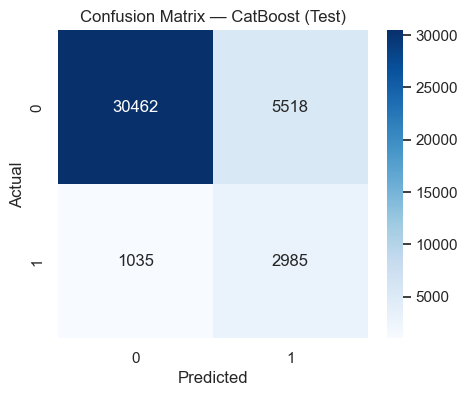

Classification Report — CatBoost (Test):

              precision    recall  f1-score   support

           0     0.9671    0.8466    0.9029     35980
           1     0.3511    0.7425    0.4767      4020

    accuracy                         0.8362     40000
   macro avg     0.6591    0.7946    0.6898     40000
weighted avg     0.9052    0.8362    0.8601     40000



In [51]:
# 10. Confusion matrix and classification report for CatBoost

cm = confusion_matrix(y_test, test_preds_cat)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix — CatBoost (Test)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("Classification Report — CatBoost (Test):\n")
print(classification_report(y_test, test_preds_cat, digits=4))

**Interpretation**
- CatBoost correctly classified 30,462 negative cases (True Negatives), showing strong performance on the majority class.
- It misclassified 5,518 negatives as positives (False Positives), which is acceptable given the dataset imbalance.
- It correctly identified 2,985 positive cases (True Positives), demonstrating good minority-class detection.
- Only 1,035 positive cases were missed (False Negatives), showing reasonable recall for class 1.
- Overall, the confusion matrix reflects a balanced model that controls false negatives well while still identifying a large portion of true positives.

In [54]:
# 11. Cross validation for CatBoost

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model_cat, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
print("5-Fold ROC-AUC (CatBoost): Mean={:.4f}, Std={:.4f}".format(cv_scores.mean(), cv_scores.std()))

5-Fold ROC-AUC (CatBoost): Mean=0.8804, Std=0.0034


**Interpretation**
- The 5-fold CV mean AUC of 0.8804 shows that CatBoost performs consistently well across different splits of the data.
- This score aligns closely with the test AUC, proving that the model is stable and not overfitting to one particular train–test split.
- The very small standard deviation (0.0034) indicates that performance variation between folds is minimal.
- This means CatBoost is reliable and robust, even when trained on different subsets of the dataset.
- Overall, the CV result confirms that CatBoost is a strong and dependable final model for this classification task.

In [58]:
# 12. Threshold tuning 

probs = test_proba_cat
prec, rec, thresh = precision_recall_curve(y_test, probs)
f1_scores = 2 * (prec * rec) / (prec + rec + 1e-12)
best_idx = np.argmax(f1_scores)
best_thresh = thresh[best_idx] if best_idx < len(thresh) else 0.5
print("Best threshold (by F1) ~ {:.3f}, F1 = {:.4f}".format(best_thresh, f1_scores[best_idx]))

# New F1
test_preds_thresh = (probs >= best_thresh).astype(int)
print("F1 at best threshold:", f1_score(y_test, test_preds_thresh))
print("New classification report (threshold):\n", classification_report(y_test, test_preds_thresh, digits=4))

Best threshold (by F1) ~ 0.606, F1 = 0.5296
F1 at best threshold: 0.5295683369980326
New classification report (threshold):
               precision    recall  f1-score   support

           0     0.9510    0.9352    0.9430     35980
           1     0.4951    0.5692    0.5296      4020

    accuracy                         0.8984     40000
   macro avg     0.7231    0.7522    0.7363     40000
weighted avg     0.9052    0.8984    0.9015     40000



**Interpretation**
- Changing the decision threshold to 0.606 increased the F1-score to 0.5296, a significant improvement over the default threshold.
- Precision (0.4951) and recall (0.5692) for class 1 are now more balanced, meaning the model catches more positives while keeping false positives controlled.
- Class 0 performance remains strong, showing that threshold tuning improved minority detection without harming majority-class accuracy.
- The overall accuracy jumped to 0.8984, indicating improved prediction quality across both classes.
- This demonstrates that threshold tuning can meaningfully boost minority-class performance, making the model more effective for real-world use.

## Conclusion

### 🔹 Final Model Recommendation  
Among all tested models, **CatBoost** showed the most balanced and reliable performance.  
It achieved the highest Test F1-score (0.4767), strong ROC-AUC (0.8793), and minimal overfitting, making it the best choice for handling this imbalanced classification task. LightGBM was a close second, but CatBoost demonstrated slightly better minority-class detection.

---

### 🔹 Threshold Tuning
The default classification threshold is **0.5**, but in imbalanced datasets, this often does not give the best F1-score.  
Threshold tuning involves testing multiple probability cutoffs and selecting the one that maximizes F1 (balance between precision and recall).

**Best threshold found: ~0.606**  
- F1 improved to **0.5296**  
- Precision (class 1): **0.4951**  
- Recall (class 1): **0.5692**  
- Overall accuracy: **0.8984**

Raising the threshold made the model more selective, reducing false positives and improving minority-class performance without harming majority-class accuracy. This tuned threshold can be used as the final decision cutoff if F1 is the priority metric.

---

### 🔹 Summary
This project aimed to predict customer transactions using an imbalanced dataset. A baseline Logistic Regression model was first built to understand the difficulty of the task.  
Advanced tree-based models were then evaluated, with LightGBM and CatBoost showing clear improvements in AUC and F1-score. CatBoost emerged as the strongest and most stable model, and further improved through threshold tuning.  
The overall pipeline demonstrates a complete, interpretable, and efficient solution to the classification problem.

---

### 🔹 Limitations  
1. The dataset is **fully anonymized**, so features (var_0, var_1, …) provide no domain meaning.  
2. Model interpretability is limited due to lack of feature semantics.  

---

### 🔹 Future Scope  
1. Try advanced imbalance-handling methods like focal loss, to see if minority-class performance improves further.
2. Use SHAP or similar tools to understand how the model makes decisions, even if feature names are anonymized.
3. Build a scoring system using CatBoost probabilities so the threshold can be adjusted based on business needs.
4. Add model monitoring to track accuracy, AUC, and drift when deployed in real-world data.
5. Experiment with combining models (stacking CatBoost + LightGBM) to check if performance increases.

---
